# Лабораторная работа недели 1: научите линию учиться
## Linear regression: от основных принципов до PyTorch

**Ожидаемое время выполнения:** 90 минут  
**Что нужно сдать:** заполненный notebook, в котором проходят все проверки, и краткие письменные интерпретации  
**Максимальная оценка:** 4 балла

В этой лабораторной работе вы обучите свою первую machine-learning model. Одну задачу noisy regression мы решим тремя способами:

1. NumPy с gradients, выведенными вручную;
2. PyTorch с automatic differentiation;
3. PyTorch с `Dataset`, `DataLoader` и mini-batches.

Model остаётся той же. Меняется способ вычисления gradients и передачи data в training loop.

## Пять составляющих ML task

К концу лабораторной работы вы должны уметь определять:

- **data:** значения input и target;
- **model:** правило, преобразующее input в prediction;
- **loss:** число, измеряющее prediction error;
- **optimization:** повторяющиеся обновления parameters, уменьшающие training loss;
- **evaluation:** результаты на data, которые не использовались для обновления parameters.

Выполните по порядку восемь заданий `TODO(student)`. Не изменяйте seed, split или assertions только ради прохождения проверки.

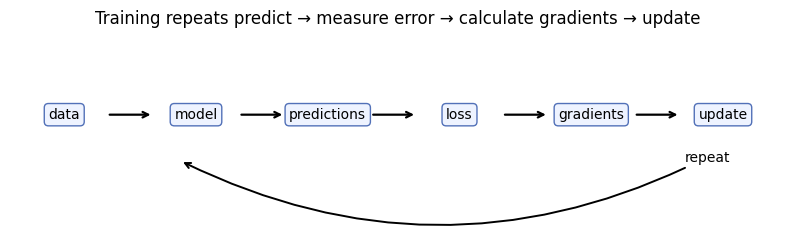

In [1]:
# @title Diagram: the learning loop
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.4))
ax.axis("off")
labels = ["data", "model", "predictions", "loss", "gradients", "update"]
positions = [0.07, 0.24, 0.41, 0.58, 0.75, 0.92]
for x, label in zip(positions, labels):
    ax.text(x, .55, label, ha="center", va="center",
            bbox=dict(boxstyle="round", fc="#EEF3FF", ec="#5271B8"))
for left, right in zip(positions[:-1], positions[1:]):
    ax.annotate("", (right - .055, .55), (left + .055, .55),
                arrowprops=dict(arrowstyle="->", lw=1.6))
ax.annotate("repeat", (.22, .30), (.90, .30), ha="center",
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-.25", lw=1.4))
ax.set_title("Training repeats predict → measure error → calculate gradients → update")
plt.show()

## Знакомство с data · 10 минут

Мы генерируем небольшой synthetic dataset по формуле

$$
y = 1.75x - 0.40 + \varepsilon,
\qquad
\varepsilon \sim \mathcal{N}(0,0.45^2).
$$

Здесь $x$ — **input**, $y$ — **target**, а $\varepsilon$ — random noise. Из-за noise наблюдения не лежат идеально на одной линии.

Мы отделяем validation observations до начала fitting. Каждая implementation будет использовать одни и те же training data и validation data.

In [2]:
import random

import numpy as np
import torch
from IPython.display import Markdown, display
from torch import nn
from torch.utils.data import DataLoader, Dataset

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TRUE_W, TRUE_B = 1.75, -0.40

In [3]:
rng = np.random.default_rng(SEED)
x_all = np.linspace(-3.0, 3.0, 160, dtype=np.float64).reshape(-1, 1)
noise = rng.normal(0.0, 0.45, size=x_all.shape)
y_all = TRUE_W * x_all + TRUE_B + noise

permutation = rng.permutation(len(x_all))
split = int(0.8 * len(x_all))
train_ids, val_ids = permutation[:split], permutation[split:]
x_train_np, y_train_np = x_all[train_ids], y_all[train_ids]
x_val_np, y_val_np = x_all[val_ids], y_all[val_ids]

assert len(x_train_np) == 128 and len(x_val_np) == 32
assert set(train_ids).isdisjoint(val_ids)
assert x_train_np.shape == y_train_np.shape == (128, 1)
print("training:", x_train_np.shape, "| validation:", x_val_np.shape)

training: (128, 1) | validation: (32, 1)


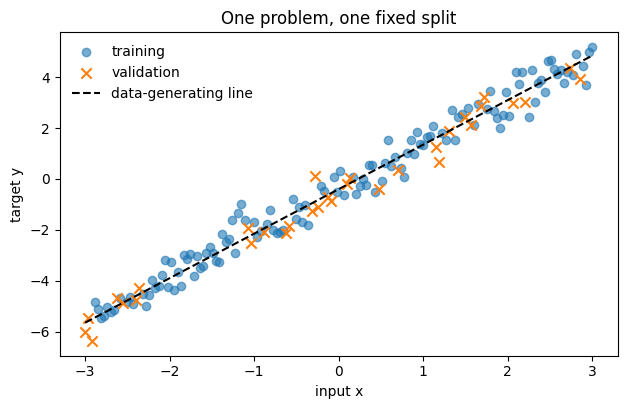

In [4]:
x_line = np.linspace(-3.0, 3.0, 200)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.scatter(x_train_np, y_train_np, alpha=.6, label="training")
ax.scatter(x_val_np, y_val_np, marker="x", s=55, label="validation")
ax.plot(x_line, TRUE_W * x_line + TRUE_B, "k--", label="data-generating line")
ax.set(xlabel="input x", ylabel="target y", title="One problem, one fixed split")
ax.legend(frameon=False)
plt.show()

Наша model — ещё одна линия:

$$
\hat y = wx+b.
$$

Prediction обозначается как $\hat y$. **Parameters** $w$ и $b$ — это числа, которые будут изменяться во время training. Начинаем с $w=0$ и $b=0$: они задают горизонтальную линию и дают неточные predictions.

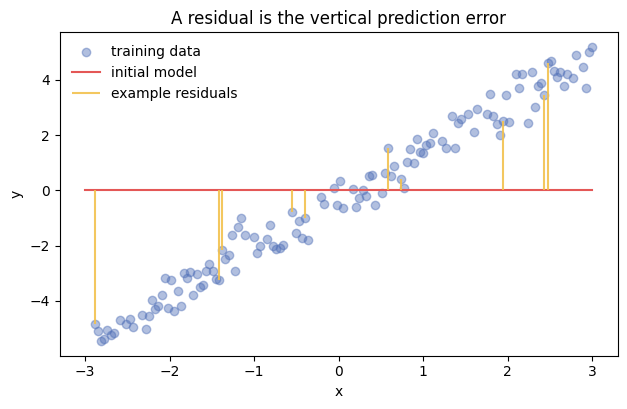

In [ ]:
initial_predictions = np.zeros_like(y_train_np)
example_ids = np.arange(10)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.scatter(x_train_np, y_train_np, color="#5271B8", alpha=.45, label="training data")
ax.plot(x_line, np.zeros_like(x_line), color="#E45656", label="initial model")
ax.vlines(x_train_np[example_ids, 0], 0, y_train_np[example_ids, 0],
          color="#F2C14E", alpha=.9, label="example residuals")
ax.set(xlabel="x", ylabel="y", title="A residual is the vertical prediction error")
ax.legend(frameon=False)
plt.show()

## Loss и три вида gradient · 20 минут

Residual — это prediction минус target:

$$
r_i=\hat y_i-y_i.
$$

Mean squared error усредняет квадраты residuals:

$$
L=\operatorname{MSE}(y,\hat y)
=\frac{1}{N}\sum_{i=1}^{N}(\hat y_i-y_i)^2.
$$

Меньшее значение MSE означает, что predictions в среднем ближе к targets. Возведение в квадрат не позволяет положительным и отрицательным residuals взаимно компенсироваться.

### Задание 1/8 — Реализуйте mean squared error

In [6]:
def mse_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

In [7]:
simple_targets = np.array([0.0, 2.0])
simple_predictions = np.array([0.0, 4.0])
assert np.isclose(mse_loss(simple_targets, simple_predictions), 2.0)
print("Task 1 passed: the simple MSE is 2.0")

Task 1 passed: the simple MSE is 2.0


### Numerical differentiation

Gradient показывает, как изменяется loss при изменении parameter. Не выводя формулу, можно немного сдвинуть parameter в обе стороны и посмотреть на loss:

$$
\frac{\partial L}{\partial w}
\approx
\frac{L(w+h,b)-L(w-h,b)}{2h}.
$$

Эта **central finite difference** является приближением. Для неё нужно вычислять loss вблизи текущего значения parameter.

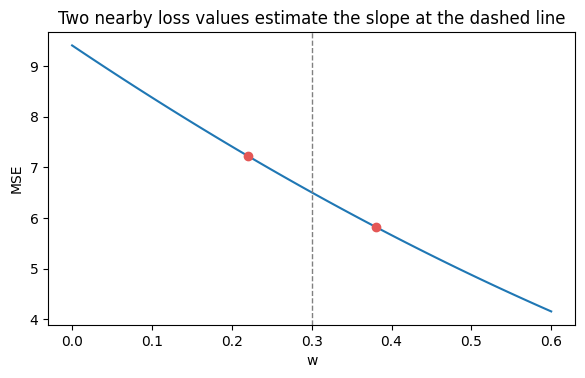

In [8]:
check_w, check_b, check_h = 0.30, -0.20, 1e-5
visual_h = 0.08  # exaggerated only so the two plotted points are visible
w_values = np.linspace(check_w - .30, check_w + .30, 120)
losses_near_w = [mse_loss(y_train_np, w * x_train_np + check_b) for w in w_values]

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(w_values, losses_near_w)
ax.scatter([check_w - visual_h, check_w + visual_h],
           [mse_loss(y_train_np, (check_w - visual_h) * x_train_np + check_b),
            mse_loss(y_train_np, (check_w + visual_h) * x_train_np + check_b)],
           color="#E45756", zorder=3)
ax.axvline(check_w, color="gray", ls="--", lw=1)
ax.set(xlabel="w", ylabel="MSE", title="Two nearby loss values estimate the slope at the dashed line")
plt.show()

### Задание 2/8 — Реализуйте numerical gradients

In [9]:
def numerical_gradients(x, y, w, b, h=1e-5):
    return (mse_loss(y, (w + h) * x + b) - mse_loss(y, (w - h) * x + b)) / (2 * h), (mse_loss(y, w * x + (b + h)) - mse_loss(y, w * x + (b - h))) / (2 * h) 

In [10]:
numerical_dw, numerical_db = numerical_gradients(
    x_train_np, y_train_np, check_w, check_b, check_h
)
assert np.isfinite(numerical_dw) and np.isfinite(numerical_db)
print(f"numerical: dL/dw={numerical_dw:.6f}, dL/db={numerical_db:.6f}")

numerical: dL/dw=-8.740177, dL/db=0.226318


### Analytical differentiation

Для этой model и MSE математический анализ даёт точные формулы:

$$
\frac{\partial L}{\partial w}
=\frac{2}{N}\sum_i x_i(\hat y_i-y_i),
$$

$$
\frac{\partial L}{\partial b}
=\frac{2}{N}\sum_i(\hat y_i-y_i).
$$

Error term $\hat y-y$ присутствует в обеих derivatives. Gradient для slope также содержит $x$, поскольку изменение slope влияет на predictions пропорционально input.

### Задание 3/8 — Реализуйте analytical gradients

In [11]:
def analytical_gradients(x, y_true, y_pred):
    n = len(y_true)
    return 2 / n * np.sum(x * (y_pred - y_true)), 2 / n * np.sum(y_pred - y_true)

In [12]:
check_predictions = check_w * x_train_np + check_b
analytical_dw, analytical_db = analytical_gradients(
    x_train_np, y_train_np, check_predictions
)
assert np.allclose(
    [numerical_dw, numerical_db], [analytical_dw, analytical_db], atol=1e-5
)
print(f"analytical: dL/dw={analytical_dw:.6f}, dL/db={analytical_db:.6f}")
print("Task 3 passed: numerical and analytical gradients agree.")

analytical: dL/dw=-8.740177, dL/db=0.226318
Task 3 passed: numerical and analytical gradients agree.


### Automatic differentiation

PyTorch **autograd** записывает tensor operations и применяет к ним chain rule в обратном направлении. Это не finite differences, и соседние значения parameters здесь не перебираются.

Теперь запросим у autograd gradient точно при тех же parameters, что использовались выше.

In [13]:
x_check = torch.tensor(x_train_np, dtype=torch.float64)
y_check = torch.tensor(y_train_np, dtype=torch.float64)
w_check = torch.tensor(check_w, dtype=torch.float64, requires_grad=True)
b_check = torch.tensor(check_b, dtype=torch.float64, requires_grad=True)

autograd_loss = ((w_check * x_check + b_check - y_check) ** 2).mean()
autograd_loss.backward()
autograd_dw = w_check.grad.item()
autograd_db = b_check.grad.item()

assert np.allclose([autograd_dw, autograd_db],
                   [analytical_dw, analytical_db], atol=1e-10)
print(f"autograd:  dL/dw={autograd_dw:.6f}, dL/db={autograd_db:.6f}")

autograd:  dL/dw=-8.740177, dL/db=0.226318


| Method | dL/dw | dL/db | distance from analytical |
|---|---:|---:|---:|
| Numerical | -8.740177 | 0.226318 | 1.33e-11 |
| Analytical | -8.740177 | 0.226318 | 0.00e+00 |
| Autograd | -8.740177 | 0.226318 | 2.78e-17 |


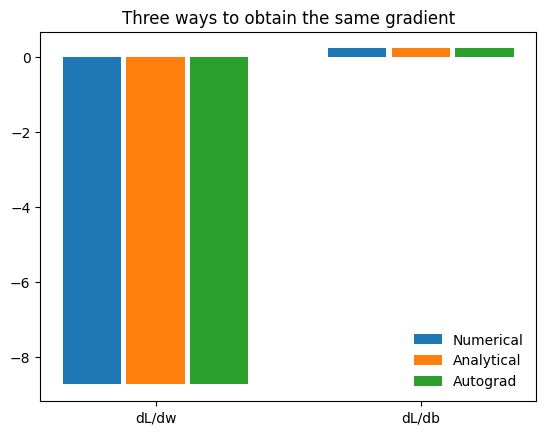

In [14]:
gradient_rows = [
    ("Numerical", numerical_dw, numerical_db),
    ("Analytical", analytical_dw, analytical_db),
    ("Autograd", autograd_dw, autograd_db),
]
table = "| Method | dL/dw | dL/db | distance from analytical |\n|---|---:|---:|---:|\n"
for name, dw, db in gradient_rows:
    difference = np.linalg.norm([dw - analytical_dw, db - analytical_db])
    table += f"| {name} | {dw:.6f} | {db:.6f} | {difference:.2e} |\n"
display(Markdown(table))

positions = np.arange(2)
for offset, (name, dw, db) in zip([-.24, 0, .24], gradient_rows):
    plt.bar(positions + offset, [dw, db], width=.22, label=name)
plt.xticks(positions, ["dL/dw", "dL/db"])
plt.title("Three ways to obtain the same gradient")
plt.legend(frameon=False)
plt.show()

**Checkpoint.** Numerical differentiation полезна для проверки gradient, но требует дополнительных вычислений loss для каждого parameter. Autograd может вычислить gradients для миллионов parameters за один backward pass.

В следующем эксперименте меняется step size для finite difference. Для этого конкретного quadratic loss central difference математически точна, если не учитывать floating-point effects. Чрезмерно малые шаги на самом деле дают худший результат, потому что начинают преобладать ошибки вычитания и округления. Для более общих losses слишком большой шаг также может приводить к approximation error.

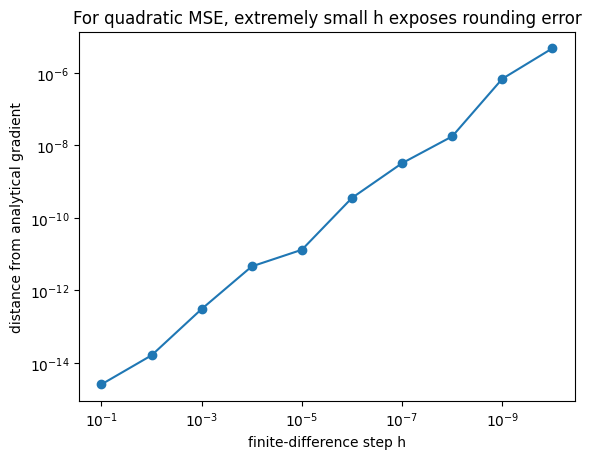

In [15]:
step_sizes = np.logspace(-1, -10, 10)
approximation_errors = []
for h in step_sizes:
    dw, db = numerical_gradients(x_train_np, y_train_np, check_w, check_b, h)
    approximation_errors.append(np.linalg.norm([dw - analytical_dw, db - analytical_db]))

plt.loglog(step_sizes, approximation_errors, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("finite-difference step h")
plt.ylabel("distance from analytical gradient")
plt.title("For quadratic MSE, extremely small h exposes rounding error")
plt.show()

## Решение 1 — NumPy gradient descent · 15 минут

Gradient descent сдвигает каждый parameter в направлении, противоположном его gradient:

$$
w \leftarrow w-\eta\frac{\partial L}{\partial w},
\qquad
b \leftarrow b-\eta\frac{\partial L}{\partial b}.
$$

Learning rate $\eta$ управляет step size. Во время training прогресс будет выводиться каждые 25 epochs, чтобы не заполнять notebook 150 строками.

### Задание 4/8 — Завершите обновление parameters в NumPy

In [16]:
w_np, b_np = 0.0, 0.0
learning_rate = 0.05
numpy_losses = []
numpy_snapshots = {-1: (w_np, b_np)}

for epoch in range(150):
    predictions = w_np * x_train_np + b_np
    loss = mse_loss(y_train_np, predictions)
    dw, db = analytical_gradients(x_train_np, y_train_np, predictions)

    w_np -= learning_rate * dw
    b_np -= learning_rate * db

    numpy_losses.append(loss)
    if epoch in {0, 5, 25, 149}:
        numpy_snapshots[epoch] = (w_np, b_np)
    if epoch % 25 == 0 or epoch == 149:
        print(f"epoch {epoch:3d} | train MSE {loss:.4f} | w {w_np:.3f} | b {b_np:.3f}")

epoch   0 | train MSE 9.4848 | w 0.528 | b -0.031
epoch  25 | train MSE 0.2286 | w 1.732 | b -0.321
epoch  50 | train MSE 0.2279 | w 1.733 | b -0.342
epoch  75 | train MSE 0.2279 | w 1.733 | b -0.344
epoch 100 | train MSE 0.2279 | w 1.733 | b -0.344
epoch 125 | train MSE 0.2279 | w 1.733 | b -0.344
epoch 149 | train MSE 0.2279 | w 1.733 | b -0.344


In [17]:
numpy_train_predictions = w_np * x_train_np + b_np
numpy_val_predictions = w_np * x_val_np + b_np
numpy_train_mse = mse_loss(y_train_np, numpy_train_predictions)
numpy_val_mse = mse_loss(y_val_np, numpy_val_predictions)

assert numpy_losses[-1] < 0.1 * numpy_losses[0]
assert abs(w_np - TRUE_W) < 0.15 and abs(b_np - TRUE_B) < 0.15
print(f"final NumPy parameters: w={w_np:.3f}, b={b_np:.3f}")
print(f"validation MSE: {numpy_val_mse:.4f}")

final NumPy parameters: w=1.733, b=-0.344
validation MSE: 0.2236


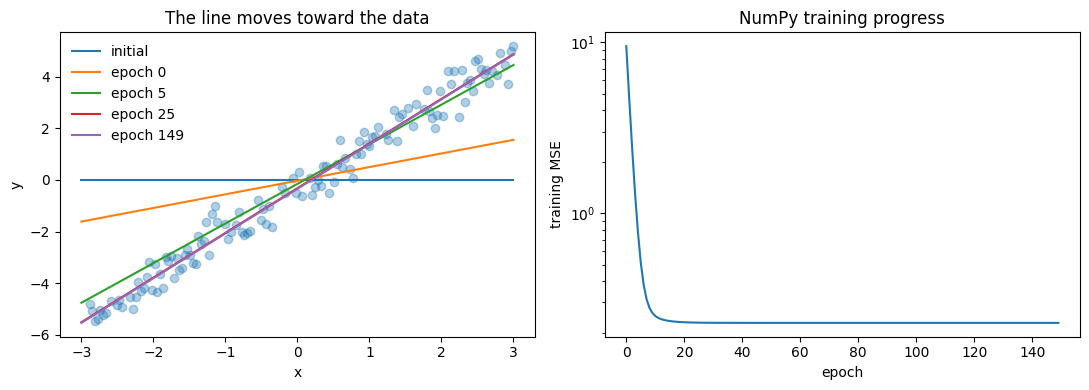

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(x_train_np, y_train_np, alpha=.35)
for epoch, (w, b) in numpy_snapshots.items():
    label = "initial" if epoch == -1 else f"epoch {epoch}"
    ax1.plot(x_line, w * x_line + b, label=label)
ax1.set(title="The line moves toward the data", xlabel="x", ylabel="y")
ax1.legend(frameon=False)

ax2.plot(numpy_losses)
ax2.set(title="NumPy training progress", xlabel="epoch", ylabel="training MSE")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()

Сначала линия быстро изменяется, а затем стабилизируется. Loss curve показывает, что обновления улучшили predictions на training data. Validation MSE позволяет проверить, насколько хорошо fitted line предсказывает также held-out observations.

## Решение 2 — Та же model с PyTorch · 25 минут

PyTorch tensor похож на NumPy array, но также может участвовать в automatic differentiation. Преобразуем тот же фиксированный split в tensors типа `float32`.

In [19]:
x_train = torch.tensor(x_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
x_val = torch.tensor(x_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.float32)

assert x_train.shape == y_train.shape == (128, 1)
assert x_val.shape == y_val.shape == (32, 1)
print("one sample:", x_train[0], "→ target", y_train[0])

one sample: tensor([-0.3962]) → target tensor([-1.0171])


| Понятие ML | Объект PyTorch |
|---|---|
| linear model | `nn.Linear(1, 1)` |
| mean squared error | `nn.MSELoss()` |
| update rule | `torch.optim.SGD` |
| вычисление gradients | `loss.backward()` |
| сброс сохранённых gradients | `optimizer.zero_grad()` |

`nn.Linear(1, 1)` содержит ровно две уже знакомые trainable quantities: один weight и один bias.

### Задание 5/8 — Создайте model, loss и optimizer

In [20]:
torch.manual_seed(SEED)

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD([model.weight, model.bias], lr=0.05)

In [21]:
assert isinstance(model, nn.Linear)
assert model.in_features == 1 and model.out_features == 1
assert isinstance(criterion, nn.MSELoss)
assert len(list(model.parameters())) == 2
print("Task 5 passed: the model has one weight and one bias.")

Task 5 passed: the model has one weight and one bias.


Один training step должен выполняться в следующем порядке:

```text
predictions = model(inputs)
loss = criterion(predictions, targets)
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

По умолчанию PyTorch накапливает gradients, поэтому `zero_grad()` не позволяет gradients с предыдущих шагов добавляться к текущему шагу.

### Задание 6/8 — Завершите training step в PyTorch

In [22]:
torch_losses = []

for epoch in range(150):
    predictions = model(x_train)
    loss = criterion(predictions, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    torch_losses.append(loss.item())
    if epoch % 25 == 0 or epoch == 149:
        w_now, b_now = model.weight.item(), model.bias.item()
        print(f"epoch {epoch:3d} | train MSE {loss.item():.4f} | w {w_now:.3f} | b {b_now:.3f}")

epoch   0 | train MSE 18.2576 | w 0.046 | b -0.476
epoch  25 | train MSE 0.2280 | w 1.733 | b -0.352
epoch  50 | train MSE 0.2279 | w 1.733 | b -0.345
epoch  75 | train MSE 0.2279 | w 1.733 | b -0.344
epoch 100 | train MSE 0.2279 | w 1.733 | b -0.344
epoch 125 | train MSE 0.2279 | w 1.733 | b -0.344
epoch 149 | train MSE 0.2279 | w 1.733 | b -0.344


In [23]:
model.eval()
with torch.no_grad():
    torch_train_predictions = model(x_train)
    torch_val_predictions = model(x_val)
    torch_train_mse = criterion(torch_train_predictions, y_train).item()
    torch_val_mse = criterion(torch_val_predictions, y_val).item()

torch_w, torch_b = model.weight.item(), model.bias.item()
assert torch_losses[-1] < 0.1 * torch_losses[0]
assert abs(torch_w - w_np) < 0.05 and abs(torch_b - b_np) < 0.05
print(f"final PyTorch parameters: w={torch_w:.3f}, b={torch_b:.3f}")
print(f"validation MSE: {torch_val_mse:.4f}")

final PyTorch parameters: w=1.733, b=-0.344
validation MSE: 0.2236


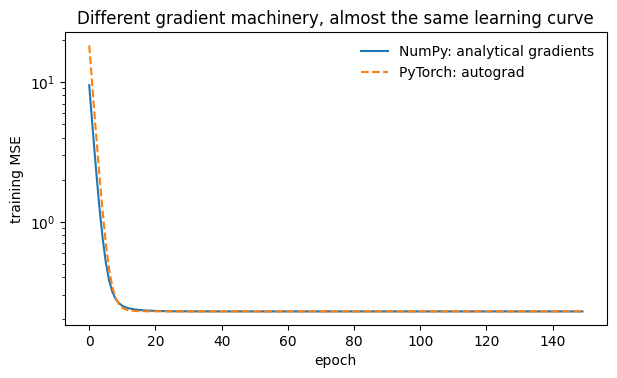

In [24]:
plt.figure(figsize=(7, 3.8))
plt.plot(numpy_losses, label="NumPy: analytical gradients")
plt.plot(torch_losses, "--", label="PyTorch: autograd")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("training MSE")
plt.title("Different gradient machinery, almost the same learning curve")
plt.legend(frameon=False)
plt.show()

> **Milestone:** вы обучили свою первую model с помощью PyTorch.

NumPy использовал написанную вами формулу gradient. PyTorch создал gradient того же вида из записанных tensor operations. Model, loss, data, learning rate и update rule остались эквивалентными.

## Решение 3 — Dataset, DataLoader и mini-batches · 12 минут

До сих пор при каждом обновлении использовались все 128 training samples. Более крупные datasets обычно обрабатываются **mini-batches**.

- `Dataset` определяет, как получить один sample.
- `DataLoader` объединяет samples в batches и может перемешивать training order.
- Model, loss, backpropagation и optimizer step остаются прежними.

### Задание 7/8 — Реализуйте интерфейс Dataset

In [25]:
class RegressionDataset(Dataset):
    def __init__(self, features, targets):
        if len(features) != len(targets):
            raise ValueError("features and targets must have equal length")
        self.features = features
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, index):
        return self.features[index], self.targets[index]

In [26]:
train_dataset = RegressionDataset(x_train, y_train)
val_dataset = RegressionDataset(x_val, y_val)
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True,
    generator=loader_generator, num_workers=0,
)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

batch_x, batch_y = next(iter(train_loader))
assert len(train_dataset) == 128 and len(val_dataset) == 32
assert batch_x.shape == batch_y.shape == (16, 1)
print("one batch:", batch_x.shape, "inputs and", batch_y.shape, "targets")

one batch: torch.Size([16, 1]) inputs and torch.Size([16, 1]) targets


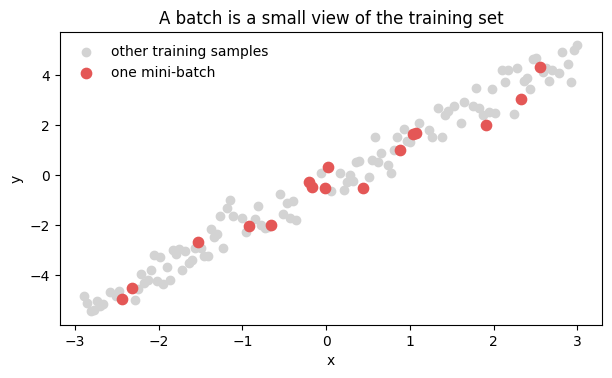

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.scatter(x_train, y_train, color="lightgray", label="other training samples")
ax.scatter(batch_x, batch_y, color="#E45756", s=55, label="one mini-batch")
ax.set(xlabel="x", ylabel="y", title="A batch is a small view of the training set")
ax.legend(frameon=False)
plt.show()

In [28]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_samples = 0.0, 0
    for features, targets in loader:
        predictions = model(features)
        loss = criterion(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(features)
        total_samples += len(features)
    return total_loss / total_samples

In [29]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for features, targets in loader:
            loss = criterion(model(features), targets)
            total_loss += loss.item() * len(features)
            total_samples += len(features)
    return total_loss / total_samples

### Задание 8/8 — Выполните training с mini-batches и отслеживайте validation loss

In [30]:
torch.manual_seed(SEED)
batch_model = nn.Linear(1, 1)
batch_criterion = nn.MSELoss()
batch_optimizer = torch.optim.SGD(batch_model.parameters(), lr=0.03)
train_history, val_history = [], []

for epoch in range(40):
    train_loss = train_one_epoch(batch_model, train_loader, batch_criterion, batch_optimizer)
    val_loss = evaluate(batch_model, val_loader, batch_criterion)
    train_history.append(train_loss)
    val_history.append(val_loss)
    
    if epoch % 5 == 0 or epoch == 39:
        print(f"epoch {epoch:2d} | train MSE {train_loss:.4f} | validation MSE {val_loss:.4f}")

epoch  0 | train MSE 6.9158 | validation MSE 0.8874
epoch  5 | train MSE 0.2306 | validation MSE 0.2237
epoch 10 | train MSE 0.2308 | validation MSE 0.2226
epoch 15 | train MSE 0.2337 | validation MSE 0.2258
epoch 20 | train MSE 0.2294 | validation MSE 0.2251
epoch 25 | train MSE 0.2298 | validation MSE 0.2252
epoch 30 | train MSE 0.2318 | validation MSE 0.2263
epoch 35 | train MSE 0.2313 | validation MSE 0.2260
epoch 39 | train MSE 0.2293 | validation MSE 0.2241


In [31]:
assert len(train_history) == len(val_history) == 40
assert train_history[-1] < 0.2 * train_history[0]
assert val_history[-1] < 0.5

batch_model.eval()
with torch.no_grad():
    batch_train_predictions = batch_model(x_train)
    batch_val_predictions = batch_model(x_val)
batch_train_mse = batch_criterion(batch_train_predictions, y_train).item()
batch_val_mse = batch_criterion(batch_val_predictions, y_val).item()
batch_w, batch_b = batch_model.weight.item(), batch_model.bias.item()

print(f"final mini-batch parameters: w={batch_w:.3f}, b={batch_b:.3f}")
print(f"validation MSE: {batch_val_mse:.4f}")
print("All eight implementation tasks passed.")

final mini-batch parameters: w=1.737, b=-0.342
validation MSE: 0.2241
All eight implementation tasks passed.


## Сравнение трёх решений · 8 минут

Результаты implementations должны быть близки, поскольку в них используются одинаковые linear model и MSE objective. Обновления с mini-batches движутся по более шумной траектории, так как при каждом обновлении видна лишь часть training set.

In [32]:
results = [
    ("NumPy", "analytical", "full batch", w_np, b_np, numpy_train_mse, numpy_val_mse),
    ("PyTorch", "autograd", "full batch", torch_w, torch_b, torch_train_mse, torch_val_mse),
    ("PyTorch", "autograd", "DataLoader", batch_w, batch_b, batch_train_mse, batch_val_mse),
]

comparison = "| Implementation | Gradients | Data feeding | w | b | Train MSE | Validation MSE |\n"
comparison += "|---|---|---|---:|---:|---:|---:|\n"
for implementation, gradients, feeding, w, b, train_mse, val_mse in results:
    comparison += (
        f"| {implementation} | {gradients} | {feeding} | {w:.3f} | {b:.3f} "
        f"| {train_mse:.4f} | {val_mse:.4f} |\n"
    )
display(Markdown(comparison))

| Implementation | Gradients | Data feeding | w | b | Train MSE | Validation MSE |
|---|---|---|---:|---:|---:|---:|
| NumPy | analytical | full batch | 1.733 | -0.344 | 0.2279 | 0.2236 |
| PyTorch | autograd | full batch | 1.733 | -0.344 | 0.2279 | 0.2236 |
| PyTorch | autograd | DataLoader | 1.737 | -0.342 | 0.2280 | 0.2241 |


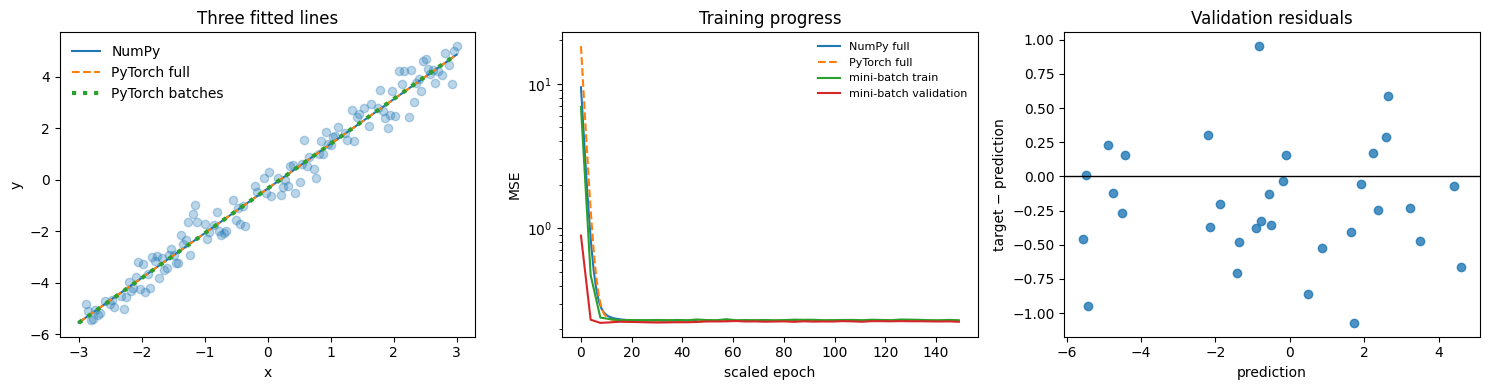

In [33]:
residuals = y_val_np - batch_val_predictions.numpy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x_train_np, y_train_np, alpha=.3)
axes[0].plot(x_line, w_np * x_line + b_np, label="NumPy")
axes[0].plot(x_line, torch_w * x_line + torch_b, "--", label="PyTorch full")
axes[0].plot(x_line, batch_w * x_line + batch_b, ":", lw=3, label="PyTorch batches")
axes[0].set(title="Three fitted lines", xlabel="x", ylabel="y")
axes[0].legend(frameon=False)

axes[1].plot(numpy_losses, label="NumPy full")
axes[1].plot(torch_losses, "--", label="PyTorch full")
axes[1].plot(np.linspace(0, 149, 40), train_history, label="mini-batch train")
axes[1].plot(np.linspace(0, 149, 40), val_history, label="mini-batch validation")
axes[1].set(title="Training progress", xlabel="scaled epoch", ylabel="MSE", yscale="log")
axes[1].legend(frameon=False, fontsize=8)

axes[2].scatter(batch_val_predictions, residuals, alpha=.8)
axes[2].axhline(0, color="black", lw=1)
axes[2].set(title="Validation residuals", xlabel="prediction", ylabel="target − prediction")
plt.tight_layout()
plt.show()

## Итоговые вопросы для интерпретации

Ответьте кратко своими словами и по возможности ссылайтесь на полученные outputs.

1. Что в этой задаче является input, target, prediction и двумя trainable parameters?
2. Что измеряет MSE? Что означало бы значение MSE, равное нулю?
3. Опишите один полный PyTorch training step в правильном порядке. Зачем нужен `zero_grad()`?
4. Почему validation observations не должны участвовать в обновлении parameters?
5. Чем отличаются numerical differentiation, analytical gradients и autograd? Почему numerical differentiation полезна, но непрактична для model с миллионами parameters?
6. Почему три implementations обучили почти одну и ту же линию? Что между ними менялось, а что оставалось неизменным?
7. Какие данные на loss curves и residual plot подтверждают — или ставят под сомнение — вывод о том, что model выучила подходящую зависимость? Что может произойти при гораздо меньшем или гораздо большем learning rate?

**Ваши ответы:**

1. input - x_all = np.linspace(-3.0, 3.0, 160, dtype=np.float64).reshape(-1, 1). target - y_all = TRUE_W * x_all + TRUE_B + noise. prediction - y' = wx + b. trainable parameters - w и b.
2. MSE - средняя квадратическая ошибка. $$\operatorname{MSE}(y,\hat y)=\frac{1}{N}\sum_{i=1}^{N}(\hat y_i-y_i)^2$$. Если MSE = 0, то наша модель ни разу не ошиблась.
3. predictions = model(inputs) -> loss = criterion(predictions, targets) -> optimizer.zero_grad() -> loss.backward() -> optimizer.step(). zero_grad() необходим для того, чтобы обнулять градиент полученный на предыдущем шаге, ведь если его не обнулить мы можем пойти не по тому направлению.
4. validation observations не участвуют в обновлении параметров, потому что мы на валидации оцениваем ошибку модели.
5. num.diff мы строим свою формулу, а anal.diff мы берем полную формулу из анализа, в autograd автоматически вычисляет gradient. numerical differentiation вычисляет loss для каждого параметра, что делает требует много вычислений.
6. Они близки ведь они используют одну и ту же модель и одну и ту же ошибку MSE. Модель и loss не менялись, менялся лишь способ прохода к нужной нам точке.
7. Все подтверждает, что выучена подходящая зависимость: train_loss и val_loss - очень близки, train_loss и val_loss уменьшаются, нет какого-либо паттерна, которого не заметила модель при обучении. Если взять очень маленький lr, то мы долго будем идти к нашей точке очень долго. Если взять lr очень большим, то мы можем перешагнуть через необходимую нам точку и не найти оптимальное значение.

## Критерии оценивания на четыре балла

| Баллы | Требуемый результат |
|---:|---|
| 1 | Правильные MSE, numerical и analytical gradients, сравнение gradients и обновления NumPy |
| 1 | Правильные PyTorch model, optimizer, autograd loop и сравнение parameters |
| 1 | Правильные `Dataset`/`DataLoader`, mini-batch training, validation и assertions |
| 1 | Воспроизводимый запуск сверху вниз, comparison table, plots и письменная интерпретация |

## Checklist перед сдачей

- [ ] Все восемь заданий `TODO(student)` выполнены.
- [ ] После перезапуска и выполнения сверху вниз проходят все assertions.
- [ ] Выводится прогресс training и отображаются все требуемые plots.
- [ ] Итоговая comparison table содержит три implementations.
- [ ] На все семь вопросов для интерпретации даны ответы своими словами.
- [ ] Training data и validation data остаются разделёнными.

## Если вам нужна помощь

<details>
<summary><strong>Откройте prompt для help-me mode в ChatGPT, Claude или другом assistant</strong></summary>

```text
You are my tutor for a Week 1 linear-regression lab. Work in help-me mode.

Do not give me a complete solution, fill every TODO, or write an entire notebook cell for me. First ask which task I am working on, then ask for my current attempt and the exact error or result I do not understand.

Give one small hint at a time. Prefer a guiding question, conceptual explanation, pseudocode, or pointer to the relevant formula or PyTorch operation. If code is necessary, show only the smallest fragment needed to explain the idea. After each hint, ask me to make the next change and report what happened.

Help me reason about data, model, predictions, MSE, numerical and analytical gradients, autograd, parameter updates, tensor shapes, Dataset/DataLoader, train/validation separation, loss curves, residuals, and assertions. Never suggest changing the seed, validation split, or tests merely to make a check pass.

I am responsible for testing, understanding, and explaining my submitted work.
```

Проверяйте каждое предложение. Никогда не вставляйте в чат пароли, tokens, приватные ссылки или персональные данные.

</details>